# Referenz-Datensatz Transformer Mit Fehler

In [1]:
import wandb
import os

# 1. Init W&B run (nutze das gleiche project/entity, in dem du trainiert hast)
run = wandb.init(
    project="Before_after_Transformer",
    entity="bat_sika",
    job_type="inference"  # kannst frei wählen
)

artifact = run.use_artifact("bat_sika/Before_after_Transformer/model-068nik0e:v0", type="model")
artifact_dir = artifact.download()  # temp-Ordner
ckpt_path = os.path.join(artifact_dir, "model.ckpt")
print("Artifact heruntergeladen nach:", ckpt_path)


wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: denis-schatzmann to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Downloading large artifact model-068nik0e:v0, 988.16MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:3.0


Artifact heruntergeladen nach: C:\FHNW_Programmiersachen\bat\code\main\notebooks\artifacts\model-068nik0e-v0\model.ckpt


In [2]:
from src.model.Vision_Transformer import VisionTransformerPretrained
import yaml
import os

os.chdir('..')


with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)
    

In [3]:


transformer_model = VisionTransformerPretrained.load_from_checkpoint(
    checkpoint_path=ckpt_path
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-384 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
transformer_model.to("cpu")
transformer_model.eval()
transformer_model.freeze()

In [5]:
import torch

dummy_input = torch.randn(1, 3, 384, 384)  # format gemäss ViT-Backbone
with torch.no_grad():
    logits = transformer_model(dummy_input)
    preds = torch.argmax(logits, dim=-1)
print("Predicted class:", preds.item())

Predicted class: 0


In [6]:
import pickle
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

with open('data/before_after_with_box/test/test_stripes.pkl', 'rb') as f:
    test_stripes = pickle.load(f)

labels =pd.read_excel('data/before_after_with_box/test/test_labels_before_after_with_box.xlsx')
    
from torchmetrics import MetricCollection
import torchmetrics
from torchvision import transforms

num_classes = 3

test_confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
test_metrics = MetricCollection({
    'precision_micro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='micro'),
    'precision_macro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
    'precision_weighted': torchmetrics.Precision(task='multiclass', num_classes=num_classes,
                                                 average='weighted'),
    'recall_micro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='micro'),
    'recall_macro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
    'recall_weighted': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='weighted'),
    'accuracy_micro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='micro'),
    'accuracy_macro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='macro'),
    'accuracy_weighted': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes,
                                               average='weighted'),
    'f1_micro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='micro'),
    'f1_macro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro'),
    'f1_weighted': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='weighted'),
}, prefix="test_")

In [7]:
from torchvision.transforms import ToPILImage

to_pil = ToPILImage()
labels_list = labels['Rating_clean'].tolist()

def combine_labels(label):
    if label == 0:
        return 0
    elif label == 1:
        return 1
    elif label == 2:
        return 1
    elif label >= 3:
        return 2
    
for i, (_, stripe) in enumerate(test_stripes.iterrows()):
    stripe_before, stripe_after = stripe['before'], stripe['after']
    stripe_before = cv2.resize(stripe_before, (192, 384))
    stripe_after = cv2.resize(stripe_after, (192, 384))
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    stripe = np.hstack((stripe_before, stripe_after))
    
    stripe = transform(stripe)
    print(f'Processing stripe {i+1}/{len(test_stripes)}')

    with torch.no_grad():
        logits = transformer_model(stripe.unsqueeze(0))
        preds = torch.argmax(logits, dim=-1)

    true = torch.tensor([combine_labels(labels_list[i])], dtype=torch.int64) 
    
    test_metrics.update(preds, true)
    test_confmat.update(preds, true)

Processing stripe 1/72
Processing stripe 2/72
Processing stripe 3/72
Processing stripe 4/72
Processing stripe 5/72
Processing stripe 6/72
Processing stripe 7/72
Processing stripe 8/72
Processing stripe 9/72
Processing stripe 10/72
Processing stripe 11/72
Processing stripe 12/72
Processing stripe 13/72
Processing stripe 14/72
Processing stripe 15/72
Processing stripe 16/72
Processing stripe 17/72
Processing stripe 18/72
Processing stripe 19/72
Processing stripe 20/72
Processing stripe 21/72
Processing stripe 22/72
Processing stripe 23/72
Processing stripe 24/72
Processing stripe 25/72
Processing stripe 26/72
Processing stripe 27/72
Processing stripe 28/72
Processing stripe 29/72
Processing stripe 30/72
Processing stripe 31/72
Processing stripe 32/72
Processing stripe 33/72
Processing stripe 34/72
Processing stripe 35/72
Processing stripe 36/72
Processing stripe 37/72
Processing stripe 38/72
Processing stripe 39/72
Processing stripe 40/72
Processing stripe 41/72
Processing stripe 42/72
P

Test Metrics:
{'test_accuracy_macro': tensor(0.8725), 'test_accuracy_micro': tensor(0.8611), 'test_accuracy_weighted': tensor(0.8611), 'test_f1_macro': tensor(0.8437), 'test_f1_micro': tensor(0.8611), 'test_f1_weighted': tensor(0.8666), 'test_precision_macro': tensor(0.8565), 'test_precision_micro': tensor(0.8611), 'test_precision_weighted': tensor(0.9034), 'test_recall_macro': tensor(0.8725), 'test_recall_micro': tensor(0.8611), 'test_recall_weighted': tensor(0.8611)}
Test Confusion Matrix:


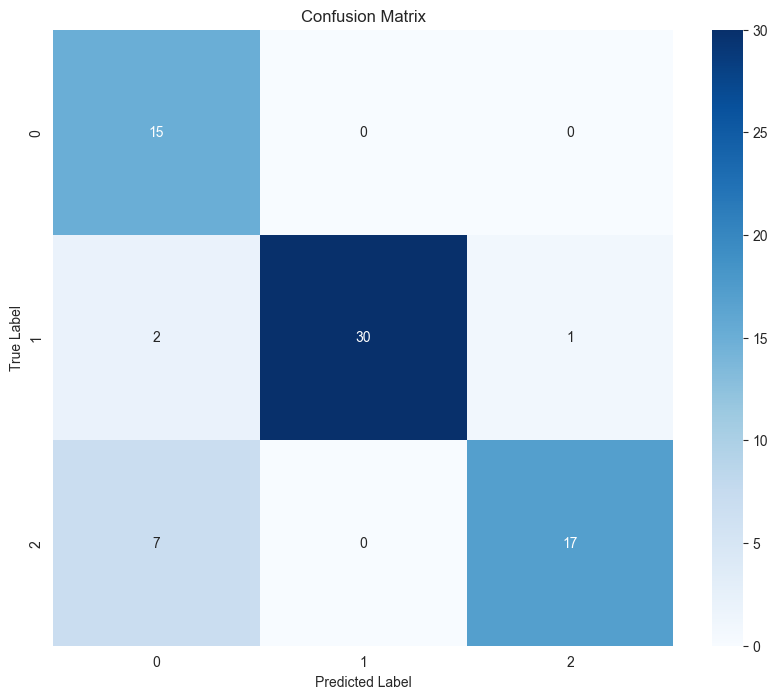

In [8]:
print("Test Metrics:")
print(test_metrics.compute())

print("Test Confusion Matrix:")
confmat = test_confmat.compute()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(confmat.numpy(), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

## Ohne Fehlerklasse

In [9]:
import wandb
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import pickle
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.model.Vision_Transformer import VisionTransformerPretrained
import yaml
import os
from torchmetrics import MetricCollection
import torchmetrics
from torchvision import transforms

#os.chdir('..')


with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)
    

run = wandb.init(
    project="Before_after_Transformer",
    entity="bat_sika",
    job_type="inference"  # kannst frei wählen
)

artifact = run.use_artifact("bat_sika/Before_after_Transformer/model-16kx17f3:v0", type="model")
artifact_dir = artifact.download()  # temp-Ordner
ckpt_path = os.path.join(artifact_dir, "model.ckpt")
print("Artifact heruntergeladen nach:", ckpt_path)

transformer_model = VisionTransformerPretrained.load_from_checkpoint(
    checkpoint_path=ckpt_path
)
transformer_model.to("cpu")
transformer_model.eval()
transformer_model.freeze()

wandb: Downloading large artifact model-16kx17f3:v0, 988.16MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:2.8


Artifact heruntergeladen nach: C:\FHNW_Programmiersachen\bat\code\main\artifacts\model-16kx17f3-v0\model.ckpt


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-384 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Processing stripe 4/72
Processing stripe 5/72
Processing stripe 6/72
Processing stripe 7/72
Processing stripe 9/72
Processing stripe 11/72
Processing stripe 13/72
Processing stripe 14/72
Processing stripe 15/72
Processing stripe 16/72
Processing stripe 17/72
Processing stripe 18/72
Processing stripe 19/72
Processing stripe 21/72
Processing stripe 22/72
Processing stripe 23/72
Processing stripe 24/72
Processing stripe 26/72
Processing stripe 27/72
Processing stripe 28/72
Processing stripe 29/72
Processing stripe 30/72
Processing stripe 31/72
Processing stripe 32/72
Processing stripe 34/72
Processing stripe 36/72
Processing stripe 37/72
Processing stripe 38/72
Processing stripe 39/72
Processing stripe 40/72
Processing stripe 41/72
Processing stripe 42/72
Processing stripe 43/72
Processing stripe 45/72
Processing stripe 47/72
Processing stripe 48/72
Processing stripe 49/72
Processing stripe 50/72
Processing stripe 51/72
Processing stripe 52/72
Processing stripe 53/72
Processing stripe 54/

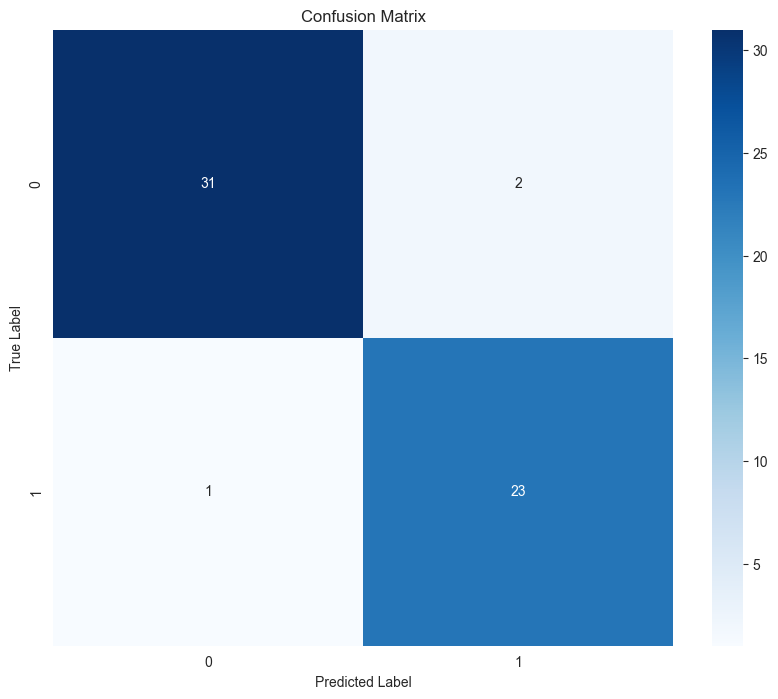

In [10]:
from torchvision.transforms import ToPILImage
import torch

with open('data/before_after_with_box/test/test_stripes.pkl', 'rb') as f:
    test_stripes = pickle.load(f)

labels =pd.read_excel('data/before_after_with_box/test/test_labels_before_after_with_box.xlsx')

to_pil = ToPILImage()
labels_list = labels['Rating_clean'].tolist()

num_classes = 2

test_confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
test_metrics = MetricCollection({
    'precision_micro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='micro'),
    'precision_macro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
    'precision_weighted': torchmetrics.Precision(task='multiclass', num_classes=num_classes,
                                                 average='weighted'),
    'recall_micro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='micro'),
    'recall_macro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
    'recall_weighted': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='weighted'),
    'accuracy_micro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='micro'),
    'accuracy_macro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='macro'),
    'accuracy_weighted': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes,
                                               average='weighted'),
    'f1_micro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='micro'),
    'f1_macro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro'),
    'f1_weighted': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='weighted'),
}, prefix="test_")

def combine_labels(label):
    if label == 1:
        return 0
    elif label == 2:
        return 0
    elif label == 3:
        return 1
    elif label >= 3:
        return 1
    
for i, (_, stripe) in enumerate(test_stripes.iterrows()):
    stripe_before, stripe_after = stripe['before'], stripe['after']
    stripe_before = cv2.resize(stripe_before, (192, 384))
    stripe_after = cv2.resize(stripe_after, (192, 384))
    
    if labels_list[i] == 0:
        continue
    true = torch.tensor([combine_labels(labels_list[i])], dtype=torch.int64) 
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
   
    stripe = np.hstack((stripe_before, stripe_after))
    
    stripe = transform(stripe)
    print(f'Processing stripe {i+1}/{len(test_stripes)}')

    with torch.no_grad():
        logits = transformer_model(stripe.unsqueeze(0))
        preds = torch.argmax(logits, dim=-1)
    
    test_metrics.update(preds, true)
    test_confmat.update(preds, true)

print("Test Metrics:")
print(test_metrics.compute())

print("Test Confusion Matrix:")
confmat = test_confmat.compute()

plt.figure(figsize=(10, 8))
sns.heatmap(confmat.numpy(), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

# ResNet18 Before After

In [11]:


import wandb
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import pickle
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.model.resnet_18 import ResNet18Pretrained
import yaml
import os
from torchmetrics import MetricCollection
import torchmetrics
from torchvision import transforms

#os.chdir('..')


with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)
    

run = wandb.init(
    project="Before_after_Transformer",
    entity="bat_sika",
    job_type="inference"  # kannst frei wählen
)

artifact = run.use_artifact("bat_sika/Before_After_Resnet18_best_training/model-ypw77ysj:v0", type="model")
artifact_dir = artifact.download()  # temp-Ordner
ckpt_path = os.path.join(artifact_dir, "model.ckpt")
print("Artifact heruntergeladen nach:", ckpt_path)

transformer_model = ResNet18Pretrained.load_from_checkpoint(
    checkpoint_path=ckpt_path
)
transformer_model.to("cpu")
transformer_model.eval()
transformer_model.freeze()


wandb: Downloading large artifact model-ypw77ysj:v0, 128.05MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.7


Artifact heruntergeladen nach: C:\FHNW_Programmiersachen\bat\code\main\artifacts\model-ypw77ysj-v0\model.ckpt


Processing stripe 1/72
Processing stripe 2/72
Processing stripe 3/72
Processing stripe 4/72
Processing stripe 5/72
Processing stripe 6/72
Processing stripe 7/72
Processing stripe 8/72
Processing stripe 9/72
Processing stripe 10/72
Processing stripe 11/72
Processing stripe 12/72
Processing stripe 13/72
Processing stripe 14/72
Processing stripe 15/72
Processing stripe 16/72
Processing stripe 17/72
Processing stripe 18/72
Processing stripe 19/72
Processing stripe 20/72
Processing stripe 21/72
Processing stripe 22/72
Processing stripe 23/72
Processing stripe 24/72
Processing stripe 25/72
Processing stripe 26/72
Processing stripe 27/72
Processing stripe 28/72
Processing stripe 29/72
Processing stripe 30/72
Processing stripe 31/72
Processing stripe 32/72
Processing stripe 33/72
Processing stripe 34/72
Processing stripe 35/72
Processing stripe 36/72
Processing stripe 37/72
Processing stripe 38/72
Processing stripe 39/72
Processing stripe 40/72
Processing stripe 41/72
Processing stripe 42/72
P

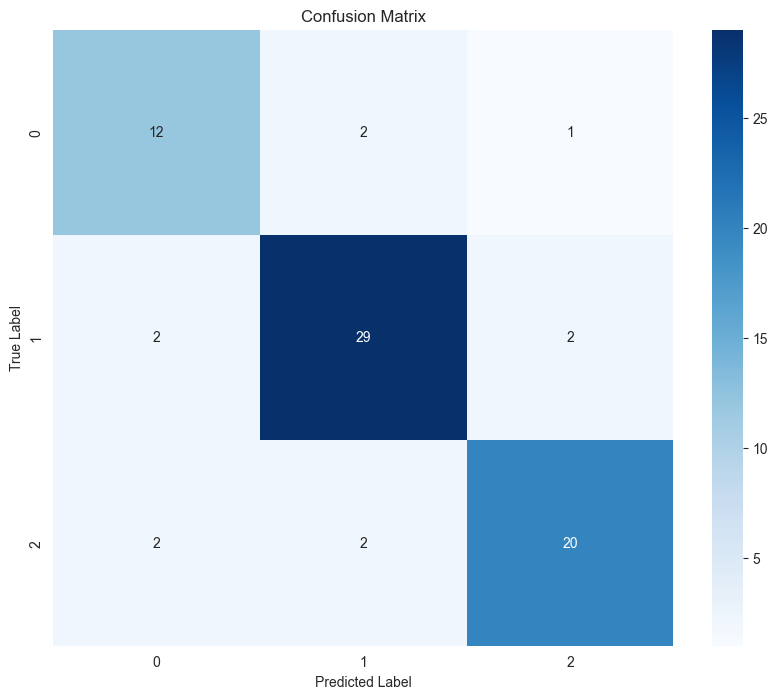

In [12]:
from torchvision.transforms import ToPILImage
import torch

with open('data/before_after_with_box/test/test_stripes.pkl', 'rb') as f:
    test_stripes = pickle.load(f)

labels =pd.read_excel('data/before_after_with_box/test/test_labels_before_after_with_box.xlsx')

to_pil = ToPILImage()
labels_list = labels['Rating_clean'].tolist()

num_classes = 3

test_confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
test_metrics = MetricCollection({
    'precision_micro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='micro'),
    'precision_macro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
    'precision_weighted': torchmetrics.Precision(task='multiclass', num_classes=num_classes,
                                                 average='weighted'),
    'recall_micro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='micro'),
    'recall_macro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
    'recall_weighted': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='weighted'),
    'accuracy_micro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='micro'),
    'accuracy_macro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='macro'),
    'accuracy_weighted': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes,
                                               average='weighted'),
    'f1_micro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='micro'),
    'f1_macro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro'),
    'f1_weighted': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='weighted'),
}, prefix="test_")

def combine_labels(label):
    if label == 0:
        return 0
    elif label == 1:
        return 1
    elif label == 2:
        return 1
    elif label >= 3:
        return 2
    
for i, (_, stripe) in enumerate(test_stripes.iterrows()):
    stripe_before, stripe_after = stripe['before'], stripe['after']
    stripe_before = cv2.resize(stripe_before, (192, 384))
    stripe_after = cv2.resize(stripe_after, (192, 384))
    
    true = torch.tensor([combine_labels(labels_list[i])], dtype=torch.int64) 
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
   
    stripe = np.hstack((stripe_before, stripe_after))
    
    stripe = transform(stripe)
    print(f'Processing stripe {i+1}/{len(test_stripes)}')

    with torch.no_grad():
        logits = transformer_model(stripe.unsqueeze(0))
        preds = torch.argmax(logits, dim=-1)
    
    test_metrics.update(preds, true)
    test_confmat.update(preds, true)

print("Test Metrics:")
print(test_metrics.compute())

print("Test Confusion Matrix:")
confmat = test_confmat.compute()

plt.figure(figsize=(10, 8))
sns.heatmap(confmat.numpy(), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

# Klassisches Modell

In [13]:
from skimage.filters import threshold_multiotsu

num_classes = 2

test_confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
test_metrics = MetricCollection({
    'precision_micro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='micro'),
    'precision_macro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
    'precision_weighted': torchmetrics.Precision(task='multiclass', num_classes=num_classes,
                                                 average='weighted'),
    'recall_micro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='micro'),
    'recall_macro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
    'recall_weighted': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='weighted'),
    'accuracy_micro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='micro'),
    'accuracy_macro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='macro'),
    'accuracy_weighted': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes,
                                               average='weighted'),
    'f1_micro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='micro'),
    'f1_macro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro'),
    'f1_weighted': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='weighted'),
}, prefix="test_")



def multi_otsu_segment(stripe_gray, n_classes=2):
    thresholds = threshold_multiotsu(stripe_gray, classes=n_classes)
    regions = np.digitize(stripe_gray, bins=thresholds)
    return regions, thresholds

def score_to_class(score):
    if score <= 0.05:
        return 1
    elif score <= 0.25:
        return 2
    elif score <= 0.75:
        return 3
    elif score <= 0.95:
        return 4
    elif score >  0.95:
        return 5
    else:
        return None
    
def combine_labels(label):
    if label == 1:
        return 0
    elif label == 2:
        return 0
    elif label == 3:
        return 1
    elif label >= 3:
        return 1
    
    
def kinked_sigmoid(x, k1=50.0, k2=50.0):
    x = np.asarray(x, dtype=float)
    sigma = lambda u: 1 / (1 + np.exp(-u))
    
    L0 = sigma(-k1*0.5)
    R1 = sigma( k2*0.5)
    
    left_raw  = sigma(k1 * (x - 0.5))
    right_raw = sigma(k2 * (x - 0.5))
    
    left  = 0.5 * (left_raw  - L0) / (0.5 - L0)
    right = 0.5 + 0.5 * (right_raw - 0.5) / (R1 - 0.5)
    
    return np.where(x <= 0.5, left, right)

def get_stripe_score_v3(stripe_pair):
    BASE_MIN_SIZE = 5000
    BASE_MAX_SIZE = 110000
    MEDIAN_HEIGT = 1360
    MEDIAN_WIDTH = 192
    AMOUNT_TO_CUT = 150
    k2 = 8
    k1 = 6
    
    stripe_before, stripe_after = stripe_pair['before'], stripe_pair['after']
    
    stripe_before = cv2.resize(stripe_before, (MEDIAN_WIDTH, MEDIAN_HEIGT))
    stripe_after = cv2.resize(stripe_after, (MEDIAN_WIDTH, MEDIAN_HEIGT))
    
    stripe_before = stripe_before[AMOUNT_TO_CUT:-AMOUNT_TO_CUT, :]
    stripe_after = stripe_after[AMOUNT_TO_CUT:-AMOUNT_TO_CUT, :]
    
    stripe_diff = cv2.absdiff(stripe_before, stripe_after)
    stripe_abs_diff_gray = cv2.cvtColor(stripe_diff, cv2.COLOR_BGR2GRAY)
    norm = stripe_abs_diff_gray.astype(np.float32) / 255.0
    regions, treshhold =  multi_otsu_segment(norm, n_classes=2)
    binary_mask = (regions == regions.max()).astype(np.uint8)
    
    total = int(np.sum(binary_mask))
    mean_diff = (total - BASE_MIN_SIZE) / BASE_MAX_SIZE

    steep_score = kinked_sigmoid(mean_diff, k1=k1, k2=k2)
    
    return binary_mask, steep_score, stripe_before, stripe_after

In [14]:
for i, (_, stripe) in enumerate(test_stripes.iterrows()):
    _, score, _, _ = get_stripe_score_v3(stripe)
    pred = combine_labels(score_to_class(score))
    true = labels_list[i]
    if true == 0:
        continue
    true = combine_labels(true)
    test_metrics.update(torch.tensor([pred]), torch.tensor([true]))
    test_confmat.update(torch.tensor([pred]), torch.tensor([true]))
    

Test Metrics:
{'test_accuracy_macro': tensor(0.7898), 'test_accuracy_micro': tensor(0.7895), 'test_accuracy_weighted': tensor(0.7895), 'test_f1_macro': tensor(0.7862), 'test_f1_micro': tensor(0.7895), 'test_f1_weighted': tensor(0.7904), 'test_precision_macro': tensor(0.7847), 'test_precision_micro': tensor(0.7895), 'test_precision_weighted': tensor(0.7933), 'test_recall_macro': tensor(0.7898), 'test_recall_micro': tensor(0.7895), 'test_recall_weighted': tensor(0.7895)}
Test Confusion Matrix:


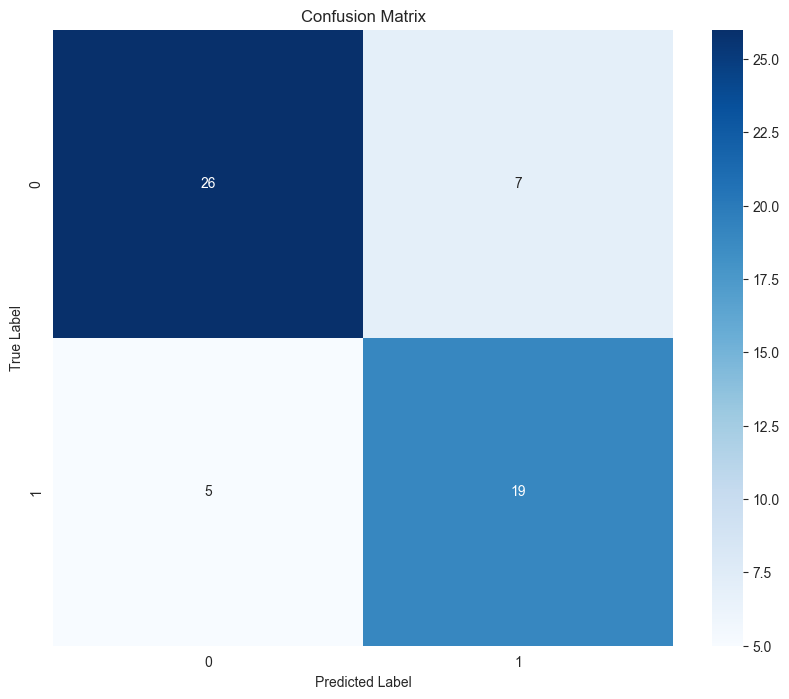

In [15]:
print("Test Metrics:")
print(test_metrics.compute())

print("Test Confusion Matrix:")
confmat = test_confmat.compute()

plt.figure(figsize=(10, 8))
sns.heatmap(confmat.numpy(), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

# Post-Peel Datensatz
## Transformer

In [16]:
import wandb
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import pickle
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.model.Vision_Transformer import VisionTransformerPretrained
import yaml
import os
from torchmetrics import MetricCollection
import torchmetrics
from torchvision import transforms

#os.chdir('..')


with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)
    

run = wandb.init(
    project="Afterfter_Transformer",
    entity="bat_sika",
    job_type="inference"  # kannst frei wählen
)

artifact = run.use_artifact("bat_sika/After_Transformer/model-4xk7sca5:v0", type="model")
artifact_dir = artifact.download()  # temp-Ordner
ckpt_path = os.path.join(artifact_dir, "model.ckpt")
print("Artifact heruntergeladen nach:", ckpt_path)

transformer_model = VisionTransformerPretrained.load_from_checkpoint(
    checkpoint_path=ckpt_path
)
transformer_model.to("cpu")
transformer_model.eval()
transformer_model.freeze()

wandb: Downloading large artifact model-4xk7sca5:v0, 988.16MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:41.5


Artifact heruntergeladen nach: C:\FHNW_Programmiersachen\bat\code\main\artifacts\model-4xk7sca5-v0\model.ckpt


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-384 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([2]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([2, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test Metrics:
{'test_accuracy_macro': tensor(0.9217), 'test_accuracy_micro': tensor(0.9455), 'test_accuracy_weighted': tensor(0.9455), 'test_f1_macro': tensor(0.9181), 'test_f1_micro': tensor(0.9455), 'test_f1_weighted': tensor(0.9458), 'test_precision_macro': tensor(0.9145), 'test_precision_micro': tensor(0.9455), 'test_precision_weighted': tensor(0.9461), 'test_recall_macro': tensor(0.9217), 'test_recall_micro': tensor(0.9455), 'test_recall_weighted': tensor(0.9455)}
Test Confusion Matrix:


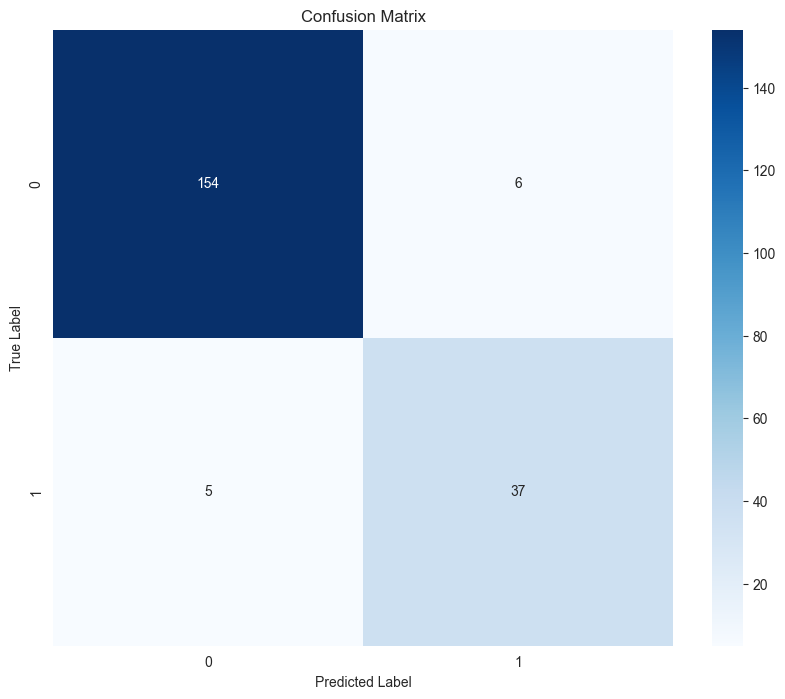

In [20]:
from torchvision.transforms import ToPILImage
import torch
from src.data.after_image_dataset import AfterImageDataset
import os

#os.chdir('..')
with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)


transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

dataset = AfterImageDataset(params, train=False, transform=transform)

num_classes = 2

test_confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
test_metrics = MetricCollection({
    'precision_micro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='micro'),
    'precision_macro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
    'precision_weighted': torchmetrics.Precision(task='multiclass', num_classes=num_classes,
                                                 average='weighted'),
    'recall_micro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='micro'),
    'recall_macro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
    'recall_weighted': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='weighted'),
    'accuracy_micro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='micro'),
    'accuracy_macro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='macro'),
    'accuracy_weighted': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes,
                                               average='weighted'),
    'f1_micro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='micro'),
    'f1_macro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro'),
    'f1_weighted': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='weighted'),
}, prefix="test_")

def combine_labels(label):
    if label == 1:
        return 0
    elif label == 2:
        return 0
    elif label == 3:
        return 1
    elif label >= 3:
        return 1
    
for datapoint in dataset:
    stripe, label = datapoint
    true = combine_labels(label)
    with torch.no_grad():
        logits = transformer_model(stripe.unsqueeze(0))
        preds = torch.argmax(logits, dim=-1)
    
    torch_preds = torch.tensor([preds.item()], dtype=torch.int64)
    torch_true = torch.tensor([true], dtype=torch.int64)
    
    test_metrics.update(torch_preds, torch_true)
    test_confmat.update(torch_preds, torch_true)

print("Test Metrics:")
print(test_metrics.compute())

print("Test Confusion Matrix:")
confmat = test_confmat.compute()

plt.figure(figsize=(10, 8))
sns.heatmap(confmat.numpy(), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

## ResNet18

In [21]:
from src.model.resnet_18 import ResNet18Pretrained

run = wandb.init(
    project="Test_runs_delete_afterwarts",
    entity="bat_sika",
    job_type="inference"  # kannst frei wählen
)

artifact = run.use_artifact("bat_sika/After_Resnet18_best_training/model-2bnx8gdz:v0", type="model")
artifact_dir = artifact.download()  # temp-Ordner
ckpt_path = os.path.join(artifact_dir, "model.ckpt")
print("Artifact heruntergeladen nach:", ckpt_path)

transformer_model = ResNet18Pretrained.load_from_checkpoint(
    checkpoint_path=ckpt_path
)
transformer_model.to("cpu")
transformer_model.eval()
transformer_model.freeze()

wandb: Downloading large artifact model-2bnx8gdz:v0, 128.05MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:8.0


Artifact heruntergeladen nach: C:\FHNW_Programmiersachen\bat\code\main\artifacts\model-2bnx8gdz-v0\model.ckpt


Test Metrics:
{'test_accuracy_macro': tensor(0.9475), 'test_accuracy_micro': tensor(0.9307), 'test_accuracy_weighted': tensor(0.9307), 'test_f1_macro': tensor(0.9044), 'test_f1_micro': tensor(0.9307), 'test_f1_weighted': tensor(0.9337), 'test_precision_macro': tensor(0.8763), 'test_precision_micro': tensor(0.9307), 'test_precision_weighted': tensor(0.9446), 'test_recall_macro': tensor(0.9475), 'test_recall_micro': tensor(0.9307), 'test_recall_weighted': tensor(0.9307)}
Test Confusion Matrix:


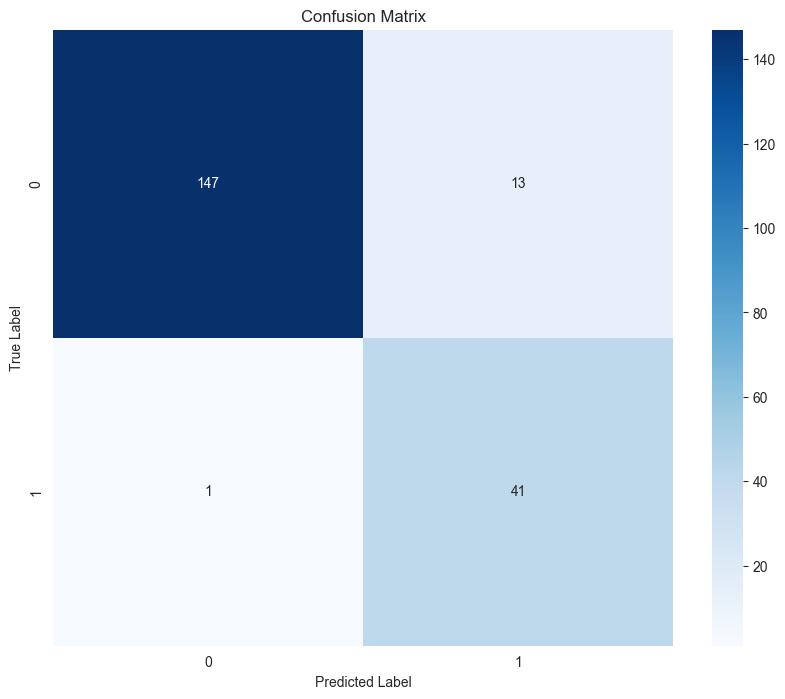

In [22]:
from torchvision.transforms import ToPILImage
import torch
from src.data.after_image_dataset import AfterImageDataset
import os

#os.chdir('..')
with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)


transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

dataset = AfterImageDataset(params, train=False, transform=transform)

num_classes = 2

test_confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
test_metrics = MetricCollection({
    'precision_micro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='micro'),
    'precision_macro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
    'precision_weighted': torchmetrics.Precision(task='multiclass', num_classes=num_classes,
                                                 average='weighted'),
    'recall_micro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='micro'),
    'recall_macro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
    'recall_weighted': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='weighted'),
    'accuracy_micro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='micro'),
    'accuracy_macro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='macro'),
    'accuracy_weighted': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes,
                                               average='weighted'),
    'f1_micro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='micro'),
    'f1_macro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro'),
    'f1_weighted': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='weighted'),
}, prefix="test_")

def combine_labels(label):
    if label == 1:
        return 0
    elif label == 2:
        return 0
    elif label == 3:
        return 1
    elif label >= 3:
        return 1
    
for datapoint in dataset:
    stripe, label = datapoint
    true = combine_labels(label)
    with torch.no_grad():
        logits = transformer_model(stripe.unsqueeze(0))
        preds = torch.argmax(logits, dim=-1)
    
    torch_preds = torch.tensor([preds.item()], dtype=torch.int64)
    torch_true = torch.tensor([true], dtype=torch.int64)
    
    test_metrics.update(torch_preds, torch_true)
    test_confmat.update(torch_preds, torch_true)

print("Test Metrics:")
print(test_metrics.compute())

print("Test Confusion Matrix:")
confmat = test_confmat.compute()

plt.figure(figsize=(10, 8))
sns.heatmap(confmat.numpy(), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

# Zusatzfehler Tranformer

In [1]:
import wandb
import seaborn as sns
import matplotlib.pyplot as plt
from torchvision.transforms import ToPILImage
import pickle
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from src.model.Vision_Transformer import VisionTransformerPretrained
import yaml
import os
from torchmetrics import MetricCollection
import torchmetrics
from torchvision import transforms
import torch

os.chdir('..')


with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)
    

run = wandb.init(
    project="Afterfter_Transformer",
    entity="bat_sika",
    job_type="inference"  # kannst frei wählen
)

artifact = run.use_artifact("bat_sika/Transformer_additional_ratings/model-068iyxio:v0", type="model")
artifact_dir = artifact.download()  # temp-Ordner
ckpt_path = os.path.join(artifact_dir, "model.ckpt")
print("Artifact heruntergeladen nach:", ckpt_path)

ckpt = torch.load(ckpt_path, map_location="cpu")
state_dict = ckpt.get("state_dict", ckpt)
transformer_model = VisionTransformerPretrained(params)  # falls nötig mit deinen Hyperparametern
transformer_model.load_state_dict(state_dict, strict=False)

transformer_model.to("cpu")
transformer_model.eval()
transformer_model.freeze()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: denis-schatzmann to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Downloading large artifact model-068iyxio:v0, 988.16MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:36.4


Artifact heruntergeladen nach: C:\FHNW_Programmiersachen\bat\code\main\artifacts\model-068iyxio-v0\model.ckpt


Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-384 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([3]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([3, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Test Metrics:
{'test_accuracy_macro': tensor(0.7877), 'test_accuracy_micro': tensor(0.9505), 'test_accuracy_weighted': tensor(0.9505), 'test_f1_macro': tensor(0.7182), 'test_f1_micro': tensor(0.9505), 'test_f1_weighted': tensor(0.9521), 'test_precision_macro': tensor(0.6891), 'test_precision_micro': tensor(0.9505), 'test_precision_weighted': tensor(0.9580), 'test_recall_macro': tensor(0.7877), 'test_recall_micro': tensor(0.9505), 'test_recall_weighted': tensor(0.9505)}
Test Confusion Matrix:


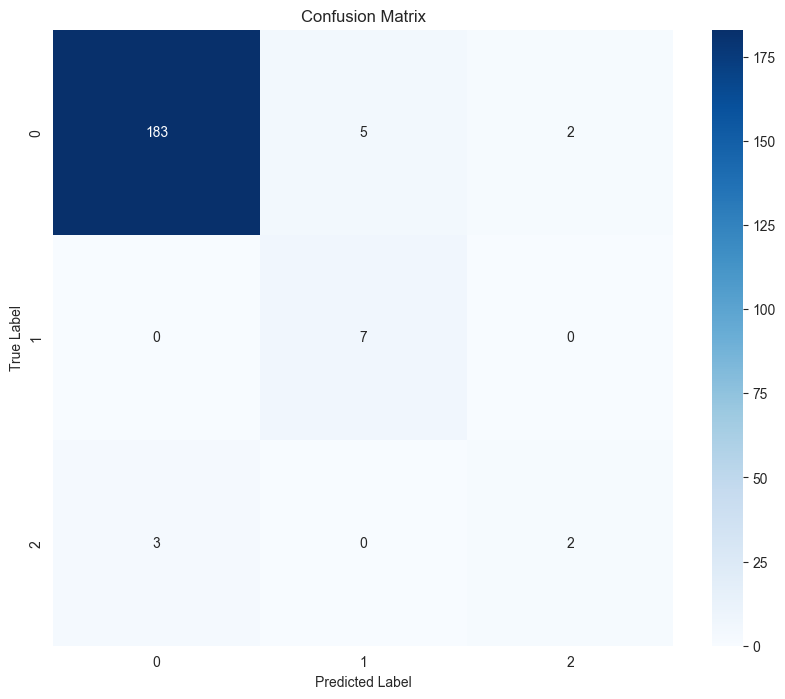

In [2]:
from torchvision.transforms import ToPILImage
import torch
from src.data.after_image_dataset import AfterImageDataset
import os

#os.chdir('..')
with open('src/params.yaml', 'r') as f:
    params = yaml.safe_load(f)


transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

dataset = AfterImageDataset(params, train=False, transform=transform)

num_classes = 3

test_confmat = torchmetrics.ConfusionMatrix(task='multiclass', num_classes=num_classes)
test_metrics = MetricCollection({
    'precision_micro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='micro'),
    'precision_macro': torchmetrics.Precision(task='multiclass', num_classes=num_classes, average='macro'),
    'precision_weighted': torchmetrics.Precision(task='multiclass', num_classes=num_classes,
                                                 average='weighted'),
    'recall_micro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='micro'),
    'recall_macro': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='macro'),
    'recall_weighted': torchmetrics.Recall(task='multiclass', num_classes=num_classes, average='weighted'),
    'accuracy_micro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='micro'),
    'accuracy_macro': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes, average='macro'),
    'accuracy_weighted': torchmetrics.Accuracy(task='multiclass', num_classes=num_classes,
                                               average='weighted'),
    'f1_micro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='micro'),
    'f1_macro': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='macro'),
    'f1_weighted': torchmetrics.F1Score(task='multiclass', num_classes=num_classes, average='weighted'),
}, prefix="test_")
    
for datapoint in dataset:
    stripe, label = datapoint
    with torch.no_grad():
        logits = transformer_model(stripe.unsqueeze(0))
        preds = torch.argmax(logits, dim=-1)
    torch_preds = torch.tensor([preds.item()], dtype=torch.int64)
    torch_true = torch.tensor([label], dtype=torch.int64)
    
    test_metrics.update(torch_preds, torch_true)
    test_confmat.update(torch_preds, torch_true)

print("Test Metrics:")
print(test_metrics.compute())

print("Test Confusion Matrix:")
confmat = test_confmat.compute()

plt.figure(figsize=(10, 8))
sns.heatmap(confmat.numpy(), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
$$
plt.show()